# Model Training

1. Import important Libraries
2. Load Featured Data
3. Define Features and Target
4. Time-Series Split
5. Evaluation Function

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import xgboost as xgb
import joblib


## Configuration

In [3]:
DATA_PATH = "../data/processed/featured_data.csv"

2. Load Featured Data


In [4]:
df = pd.read_csv(DATA_PATH, parse_dates=["date"])

df.sort_values(by=["crypto_name", "date"], inplace=True)
df.reset_index(drop=True, inplace=True)

3. Define Features and Target

In [5]:
features = [
    "open", "high", "low", "close",
    "volume", "marketCap",
    "high_low_range",
    "ATR_14",
    "bollinger_width_20",
    "liquidity_ratio",
    "volume_pct_change",
    "rolling_mean_7",
    "rolling_mean_14",
    "momentum_7"
]

target = "rolling_volatility_14"

X = df[features]
y = df[target]


4. Time-Series Split

In [6]:
split_index = int(len(df) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (57520, 14)
Test shape: (14380, 14)


5. Evaluation Function

In [7]:
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    return rmse, mae, r2, predictions


6. Model 1: Linear Regression

In [8]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_rmse, lr_mae, lr_r2, lr_preds = evaluate_model(lr_model, X_test, y_test)

print("Linear Regression Results")
print("RMSE:", lr_rmse)
print("MAE:", lr_mae)
print("R2:", lr_r2)


Linear Regression Results
RMSE: 0.5537496563673601
MAE: 0.41574713821542425
R2: -0.3878859741561702


7. Model 2: Random Forest

In [9]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_rmse, rf_mae, rf_r2, rf_preds = evaluate_model(rf_model, X_test, y_test)

print("Random Forest Results")
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)
print("R2:", rf_r2)


Random Forest Results
RMSE: 0.25302239497989193
MAE: 0.15169910743548404
R2: 0.7102357706901761


8. Model 3: XGBoost

In [10]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_rmse, xgb_mae, xgb_r2, xgb_preds = evaluate_model(xgb_model, X_test, y_test)

print("XGBoost Results")
print("RMSE:", xgb_rmse)
print("MAE:", xgb_mae)
print("R2:", xgb_r2)


XGBoost Results
RMSE: 0.2132839007656448
MAE: 0.1375470358486404
R2: 0.7941063288124931


9. Model Comparison Table

In [11]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "RMSE": [lr_rmse, rf_rmse, xgb_rmse],
    "MAE": [lr_mae, rf_mae, xgb_mae],
    "R2 Score": [lr_r2, rf_r2, xgb_r2]
})

results


,Model,RMSE,MAE,R2 Score
0,Linear Regression,0.553750,0.415747,-0.387886
1,Random Forest,0.253022,0.151699,0.710236
2,XGBoost,0.213284,0.137547,0.794106


10. Plot Actual vs Predicted

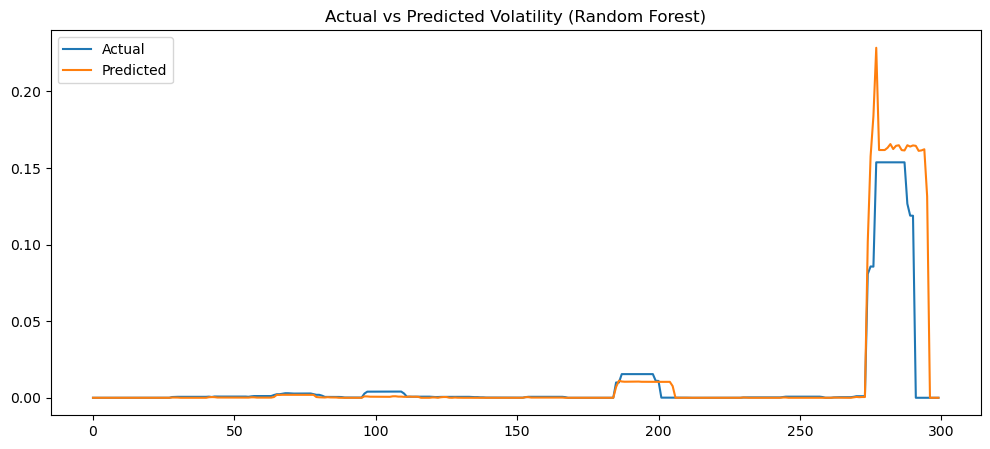

In [12]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values[:300], label="Actual")
plt.plot(rf_preds[:300], label="Predicted")
plt.title("Actual vs Predicted Volatility (Random Forest)")
plt.legend()
plt.show()


11. Save Best Model

In [13]:
joblib.dump(rf_model, "../models/volatility_model.pkl")

['../models/volatility_model.pkl']